In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('data.csv')

In [3]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [5]:

from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [6]:
# Residual
y_pred = model.predict(X_test)
residual = y_test - y_pred

# 1) linear relationship

Text(0.5, 1.0, 'Feature3')

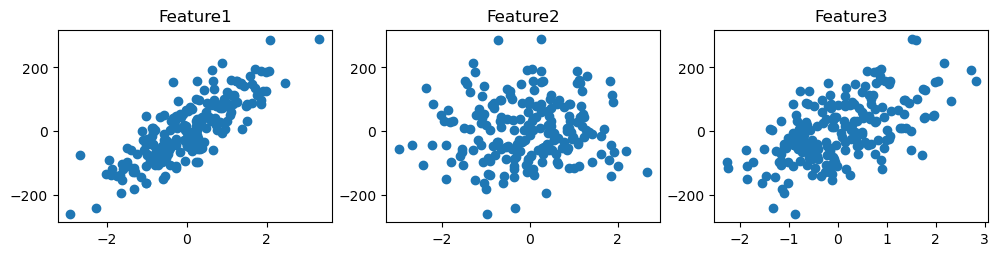

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

# multicolinearity

In [8]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [9]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T  # if 5<VIF<10 moderate multicollinearity, if VIF>10 high multicollinearity

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


<Axes: >

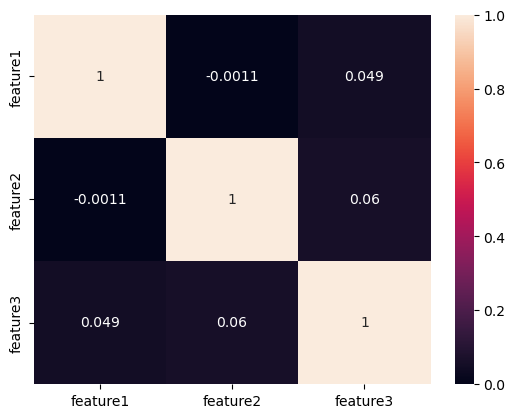

In [10]:
# Another Technique
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

# 3) normality of the residual


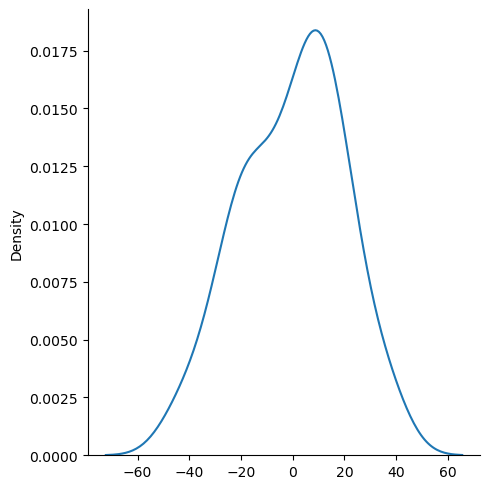

In [11]:
sns.displot(residual,kind='kde')

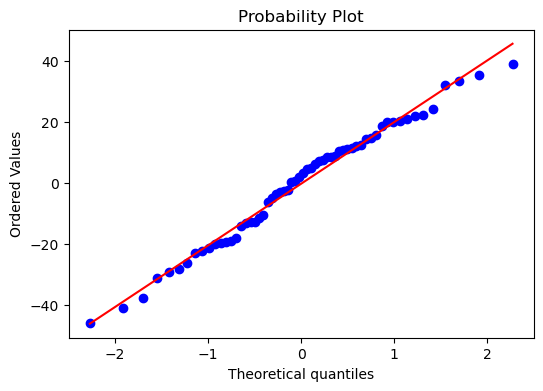

In [12]:
# QQ Plot

import scipy as sp

fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

# 4. Homoscedasticity

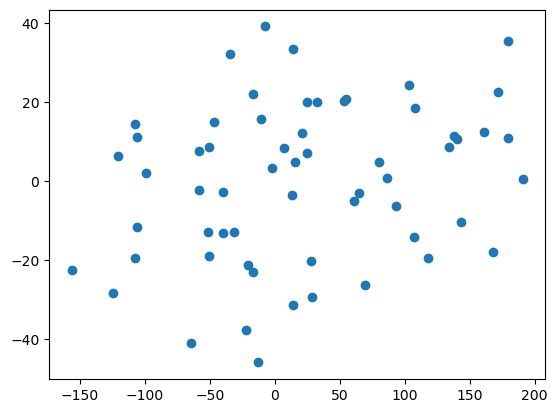

In [13]:
plt.scatter(y_pred,residual)

# 5. Autocorrelation of Residuals

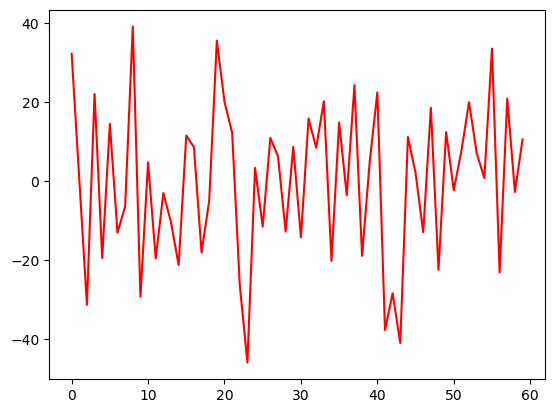

In [14]:
plt.plot(residual, color='red')